# When does white voluntarily play Rb5?

Across nearly a million master-level chess games, how often does white move a rook to b5 *without capturing anything*, how soon does it happen, and how much material is usually still on the board when it does?

Captures on b5 are filtered out throughout — we're studying the rook lift / sideways shift as a positional choice, not Rxb5 trades.

## The dataset

**Lumbra's Gigabase OTB Elite** (June 2026 release):

- ~909,000 over-the-board games (no online play, no correspondence)
- Both players Elo ≥2400 — roughly FIDE Master and above
- Aggregated across TWIC weekly tournament PGNs, the (now-defunct) Caissabase historical corpus, national federation archives (BCF, Italian, Danish, Greek, Scottish, …), and live-broadcast capture from Lichess
- Date range 1848 to 2026; sparse pre-1900 (ratings retroactively assigned), dense post-2000

Each parquet shard preserves the full original PGN per game, so we can replay every position with `python-chess` and ask move-by-move questions like the ones below.

**Sample vs full corpus.** This notebook ships with a 100-game sample under `data/sample/games/`. To run against the full ~900k-game corpus, run `make data` once (~5 min for the download + index) and flip `USE_FULL_CORPUS = True` below. Position-level analysis of the full corpus takes ~90 seconds on a 14-core mac.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq

from chess_corpus.analysis import map_shards, white_quiet_rook_to_b5

USE_FULL_CORPUS = True

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SHARD_DIR = ROOT / ("data/processed/games" if USE_FULL_CORPUS else "data/sample/games")
print(f"Reading shards from {SHARD_DIR}")

Reading shards from /Users/paul/pwsiegel/chess-move-stats/data/processed/games


/Users/paul/pwsiegel/chess-move-stats/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Replay every game and extract Rb5 stats

`white_quiet_rook_to_b5` walks each game's mainline once and records, per game, the first move number on which white moved a rook to b5 *without capturing anything*, plus the material on the board at that moment. Material is the standard P=1 N=B=3 R=5 Q=9 sum across both sides, kings excluded. Since material decreases monotonically through a game, the first Rb5 also corresponds to the highest material at any Rb5.

`map_shards` parallelizes across parquet shards (13 shards on the full corpus → one wave on 13 workers).

In [2]:
rb5 = pd.DataFrame(map_shards(white_quiet_rook_to_b5, shard_dir=SHARD_DIR))
print(f"Replayed {len(rb5):,} games.")
rb5.head()

shards:   0%|          | 0/13 [00:00<?, ?it/s]

shards:   8%|▊         | 1/13 [02:12<26:30, 132.57s/it]

shards:  15%|█▌        | 2/13 [02:15<10:18, 56.18s/it] 

shards:  23%|██▎       | 3/13 [02:17<05:14, 31.43s/it]

shards:  31%|███       | 4/13 [02:17<02:52, 19.15s/it]

...

shards:  92%|█████████▏| 12/13 [02:28<00:03,  3.08s/it]

shards: 100%|██████████| 13/13 [02:30<00:00,  2.89s/it]

shards: 100%|██████████| 13/13 [02:30<00:00, 11.61s/it]

Replayed 909,206 games.


,first_rb5_fullmove,first_rb5_material,n_white_moves
0,NaN,NaN,41
1,NaN,NaN,35
2,NaN,NaN,27
3,NaN,NaN,23
4,NaN,NaN,27


## How often does white voluntarily play Rb5?

First the unconditional rate: out of every master game in the corpus, what fraction sees white move a rook to b5 voluntarily (i.e. b5 was empty when the rook arrived)?

In [3]:
n_total = len(rb5)
n_with_rb5 = int(rb5["first_rb5_fullmove"].notna().sum())
pct = 100 * n_with_rb5 / n_total
print(f"Among all {n_total:,} games, {n_with_rb5:,} of them had white voluntarily playing Rb5 — that comes out to {pct:.2f}%.")

Among all 909,206 games, 38,462 of them had white voluntarily playing Rb5 — that comes out to 4.23%.


## When in the game does Rb5 happen? (CDF over move number)

Restrict to games where white voluntarily plays Rb5, then ask: how soon does it happen? We record the **first** move number on which white moves a rook to b5, and build a cumulative distribution: P(first Rb5 ≤ move N | white plays Rb5).

**How to read the chart:** *"Among the games where white plays Rb5, the probability that it happens by move N is Y."* For example, the cell below pulls out the value at N=30 — that's how to phrase any point on the curve.

In [4]:
played = rb5[rb5["first_rb5_fullmove"].notna()].copy()
played["first_rb5_fullmove"] = played["first_rb5_fullmove"].astype(int)
played["first_rb5_material"] = played["first_rb5_material"].astype(int)

max_n = 80
ns = np.arange(1, max_n + 1)
cdf_move = pd.DataFrame(
    {"N": ns, "prob": [(played["first_rb5_fullmove"] <= n).mean() for n in ns]}
)

example_n = 30
ex_p = cdf_move.loc[cdf_move["N"] == example_n, "prob"].iloc[0]
print(
    f"Example: among the {len(played):,} games where white plays Rb5, "
    f"the probability that it happens by move {example_n} is {ex_p:.1%}."
)

Example: among the 38,462 games where white plays Rb5, the probability that it happens by move 30 is 26.9%.


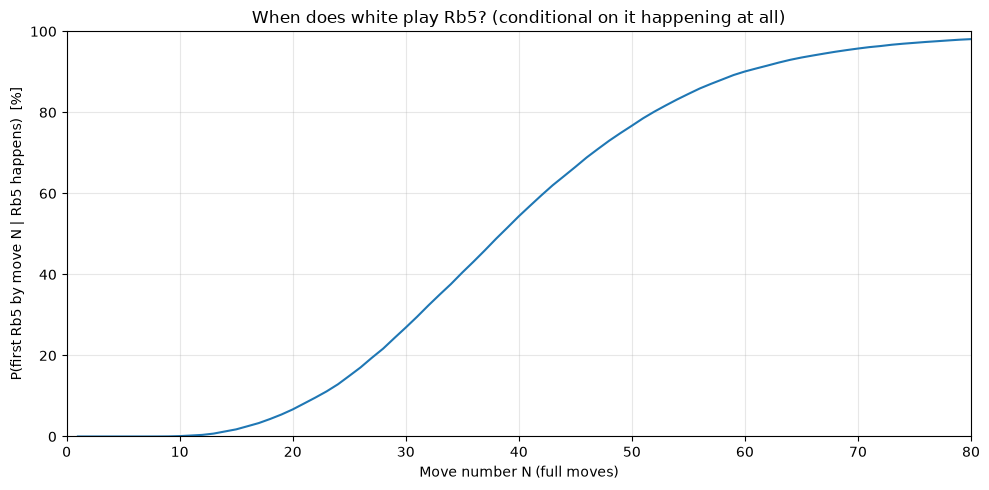

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(cdf_move["N"], cdf_move["prob"] * 100)
ax.set_xlabel("Move number N (full moves)")
ax.set_ylabel("P(first Rb5 by move N | Rb5 happens)  [%]")
ax.set_title("When does white play Rb5? (conditional on it happening at all)")
ax.grid(alpha=0.3)
ax.set_xlim(0, max_n)
ax.set_ylim(0, 100)
plt.tight_layout()
plt.show()

## How much material is on the board when Rb5 happens? (survival CDF over material)

Still restricted to games where white plays Rb5. The starting position has 78 points of material total (39 per side: 8 pawns + 2 knights + 2 bishops + 2 rooks + 1 queen). We record the material on the board immediately after the **first** Rb5 in each game — material is monotonically non-increasing during a game, so the first Rb5 is the highest-material Rb5 in the game, and "Rb5 happened with ≥ X material" is equivalent to "the first Rb5 happened with ≥ X material".

**How to read the chart:** *"Among the games where white plays Rb5, the probability that the move happens with ≥ X total points of material on the board is Y."* See the example sentence in the next cell.

In [6]:
first_mat = played["first_rb5_material"]
xs = np.arange(0, 79)
cdf_mat = pd.DataFrame({"X": xs, "prob": [(first_mat >= x).mean() for x in xs]})

example_x = 40
ex_p = cdf_mat.loc[cdf_mat["X"] == example_x, "prob"].iloc[0]
print(
    f"Example: among the {len(played):,} games where white plays Rb5, "
    f"the probability that the move happens with ≥{example_x} points of material on the board is {ex_p:.1%}."
)

Example: among the 38,462 games where white plays Rb5, the probability that the move happens with ≥40 points of material on the board is 28.2%.


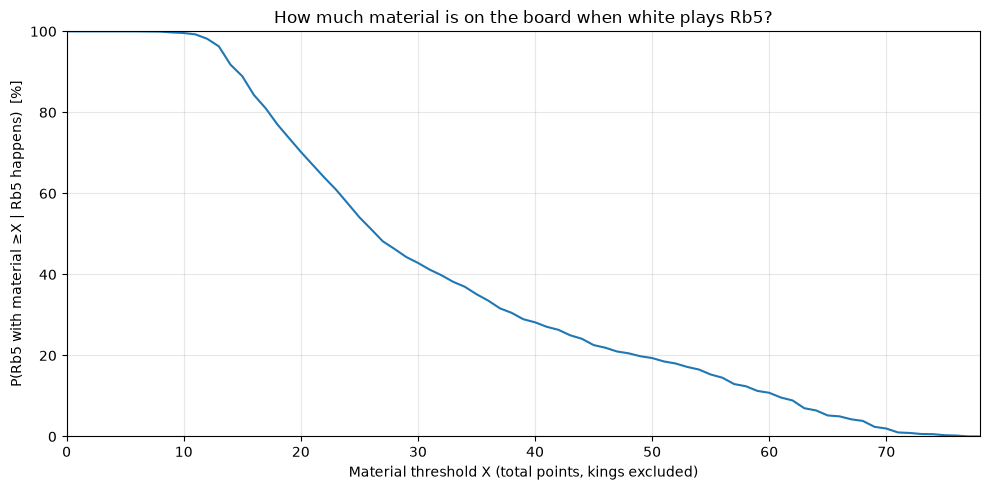

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(cdf_mat["X"], cdf_mat["prob"] * 100)
ax.set_xlabel("Material threshold X (total points, kings excluded)")
ax.set_ylabel("P(Rb5 with material ≥X | Rb5 happens)  [%]")
ax.set_title("How much material is on the board when white plays Rb5?")
ax.set_xlim(0, 78)
ax.grid(alpha=0.3)
ax.set_ylim(0, 100)
plt.tight_layout()
plt.show()

## Top 10 highest-rated players to play Rb5 by move 30

Restrict to games where white plays Rb5 on or before move 30 — that drops late-middlegame and endgame rook lifts and keeps Rb5 in its opening / early-middlegame role. Group those games by white player, take their peak rating across those games, count how many they have, sort by peak rating, top 10.

In [8]:
EARLY_RB5_MOVE = 30

# Align rb5 rows with the parquet's header columns. map_shards iterates
# sorted(glob) and preserves intra-shard order; pa.concat_tables over the
# same sorted shard list preserves the same order, so positional indices match.
shards = sorted(SHARD_DIR.glob("*.parquet"))
header_table = pa.concat_tables(
    [
        pq.read_table(
            s,
            columns=[
                "white", "white_elo", "black", "black_elo",
                "event", "date", "result", "eco", "opening",
            ],
        )
        for s in shards
    ]
)
headers_df = header_table.to_pandas().reset_index(drop=True)
combined = pd.concat([rb5.reset_index(drop=True), headers_df], axis=1)

# Games where white voluntarily plays Rb5 by move 30, with a known white Elo.
early_rb5 = combined[
    combined["first_rb5_fullmove"].notna()
    & (combined["first_rb5_fullmove"] <= EARLY_RB5_MOVE)
    & combined["white_elo"].notna()
]
print(
    f"{len(early_rb5):,} games had white play Rb5 by move {EARLY_RB5_MOVE} "
    f"(out of {int(rb5['first_rb5_fullmove'].notna().sum()):,} total Rb5 games)."
)

player_stats = (
    early_rb5.groupby("white")
    .agg(peak_elo=("white_elo", "max"), n_rb5_games=("first_rb5_fullmove", "size"))
    .reset_index()
    .sort_values("n_rb5_games", ascending=False)
)
top10_players = player_stats.head(20)
top10_players

10,343 games had white play Rb5 by move 30 (out of 38,462 total Rb5 games).


,white,peak_elo,n_rb5_games
1806,"Mamedyarov, Shakhriyar",2817,40
1285,"Ivanchuk, Vasyl",2787,37
1555,"Kramnik, Vladimir",2812,35
159,"Aronian, Levon",2815,33
2954,"Timman, Jan H",2680,32
946,"Gelfand, Boris",2751,30
167,"Artemiev, Vladislav",2754,29
289,"Beliavsky, Alexander G",2690,27
1399,"Karpov, Anatoly",2775,27
3023,"Vachier-Lagrave, Maxime",2811,26


## Players who play Rb5 most often with ≥40 material on the board

Same shape as the table above — group by white player, report peak rating and Rb5 game count — but filter to games where the first Rb5 happened with **at least 40 points of total material** on the board (Rb5 as an early- or mid-middlegame plan, not a deep-endgame rook activity), and sort by number of games. Top 10.

In [9]:
HIGH_MATERIAL_THRESHOLD = 40

high_material_rb5 = combined[
    combined["first_rb5_fullmove"].notna()
    & (combined["first_rb5_material"] >= HIGH_MATERIAL_THRESHOLD)
    & combined["white_elo"].notna()
]
print(
    f"{len(high_material_rb5):,} games had white play Rb5 with "
    f"≥{HIGH_MATERIAL_THRESHOLD} points of material on the board "
    f"(out of {int(rb5['first_rb5_fullmove'].notna().sum()):,} total Rb5 games)."
)

top10_by_count = (
    high_material_rb5.groupby("white")
    .agg(peak_elo=("white_elo", "max"), n_rb5_games=("first_rb5_fullmove", "size"))
    .reset_index()
    .sort_values("n_rb5_games", ascending=False)
    .head(10)
    .reset_index(drop=True)
)
top10_by_count

10,841 games had white play Rb5 with ≥40 points of material on the board (out of 38,462 total Rb5 games).


,white,peak_elo,n_rb5_games
0,"Ivanchuk, Vasyl",2787,35
1,"Mamedyarov, Shakhriyar",2817,35
2,"Kramnik, Vladimir",2812,32
3,"Caruana, Fabiano",2832,32
4,"Aronian, Levon",2815,31
5,"Karpov, Anatoly",2775,29
6,"Timman, Jan H",2675,29
7,"Beliavsky, Alexander G",2690,28
8,"Vachier-Lagrave, Maxime",2811,28
9,"Gelfand, Boris",2743,26


## Where does early Rb5 come from? (frequency by opening)

Group every game in the corpus by ECO code (first 3 characters of the Lumbra `eco` tag — `B23m` and `B23` collapse to `B23`), count how many of them saw white play Rb5 on or before move 30, and sort by **rate** (`early_rb5_games / total_games`) to surface the openings where Rb5 is structurally most likely. A minimum sample-size threshold (`MIN_GAMES_FOR_RATE = 500`) filters out tiny ECO buckets where 1-of-3 = 33% would otherwise dominate.

Each row carries a human-readable opening name resolved via `chess_corpus.eco_names`, which ships the canonical ECO → name mapping from the Lichess `chess-openings` repo (Lumbra itself only writes the ECO tag, not an Opening tag, so the parquet's `opening` column is mostly null).

In [10]:
from chess_corpus.eco_names import name_for

MIN_GAMES_FOR_RATE = 500  # avoid noise from tiny ECO buckets

opening_view = combined.copy()
opening_view["eco_3"] = opening_view["eco"].fillna("").str[:3]
opening_view["played_early_rb5"] = (
    opening_view["first_rb5_fullmove"].notna()
    & (opening_view["first_rb5_fullmove"] <= EARLY_RB5_MOVE)
)

agg = (
    opening_view[opening_view["eco_3"] != ""]
    .groupby("eco_3")
    .agg(
        early_rb5_games=("played_early_rb5", "sum"),
        total_games=("played_early_rb5", "size"),
    )
    .reset_index()
)
agg["opening"] = agg["eco_3"].map(name_for)
agg["rate_pct"] = 100 * agg["early_rb5_games"] / agg["total_games"]

top_openings = (
    agg[agg["total_games"] >= MIN_GAMES_FOR_RATE]
    .sort_values("rate_pct", ascending=False)
    .head(20)
    .reset_index(drop=True)
)
top_openings[["eco_3", "opening", "early_rb5_games", "total_games", "rate_pct"]]

,eco_3,opening,early_rb5_games,total_games,rate_pct
0,A18,English Opening: Mikenas-Carls Variation,56,811,6.905055
1,E25,Nimzo-Indian Defense: Sämisch Variation,47,689,6.821480
2,C19,"French Defense: Winawer Variation, Advance Var...",57,1053,5.413105
3,D80,Grünfeld Defense,74,1373,5.389658
4,A09,Réti Opening,115,2383,4.825850
5,C26,Vienna Game: Falkbeer Variation,49,1033,4.743466
6,C18,"French Defense: Winawer Variation, Advance Var...",155,3550,4.366197
7,D07,Queen's Gambit Declined: Chigorin Defense,42,1005,4.179104
8,D85,Grünfeld Defense: Exchange Variation,258,6724,3.837002
9,E13,Queen's Indian Defense: Kasparov Variation,44,1234,3.565640


### Sample games for the top 5

For each of the top 5 players, pick the game in which they played Rb5 **earliest** (smallest `first_rb5_fullmove`, breaking ties by higher Elo) and print the PGN — paste any block into a Lichess analysis board (https://lichess.org/paste).

In [11]:
pgn_table = pa.concat_tables([pq.read_table(s, columns=["pgn"]) for s in shards])
pgns = pgn_table.to_pandas().reset_index(drop=True)["pgn"]

for i, player_name in enumerate(top10_players["white"].head(5), start=1):
    # That player's earliest Rb5 game (tiebreak: highest white Elo).
    sample = (
        early_rb5[early_rb5["white"] == player_name]
        .sort_values(["first_rb5_fullmove", "white_elo"], ascending=[True, False])
        .iloc[0]
    )
    idx = sample.name

    print(
        f"# {i}. {sample['white']} ({int(sample['white_elo'])}) vs "
        f"{sample['black']} ({int(sample['black_elo']) if pd.notna(sample['black_elo']) else '?'})  "
        f"— {sample['event']}, {sample['date']}, result {sample['result']}"
    )
    print(
        f"# first Rb5: move {int(sample['first_rb5_fullmove'])} with "
        f"{int(sample['first_rb5_material'])} points of material on the board\n"
    )
    print(pgns.iloc[idx])
    print("\n" + "=" * 80 + "\n")

# 1. Mamedyarov, Shakhriyar (2766) vs Grischuk, Alexander (2764)  — Moscow Aeroflot rapid final, 2013.02.16, result 0-1
# first Rb5: move 11 with 71 points of material on the board

[Event "Moscow Aeroflot rapid final"]
[Site "Moscow RUS"]
[Date "2013.02.16"]
[Round "2.1"]
[White "Mamedyarov, Shakhriyar"]
[Black "Grischuk, Alexander"]
[Result "0-1"]
[PlyCount "71"]
[WhiteElo "2766"]
[WhiteFideId "13401319"]
[WhiteTitle "GM"]
[BlackElo "2764"]
[BlackFideId "4126025"]
[BlackTitle "GM"]
[ECO "D80"]
[Source "Codekiddy"]
[SourceQuality "3"]
[ImportDate "2026-01-06"]

1. d4 Nf6 2. c4 g6 3. Nc3 d5 4. Bg5 Ne4 5. Bh4 Nxc3 6. bxc3 dxc4 7. e3 Be6 8. Rb1 Bg7 9. Nh3 b6 10. Nf4 Bf5 11. Rb5 Bd7 12. Rb2 b5 13. Nd5 f6 14. Bg3 e5 15. dxe5 fxe5 16. Rd2 c6 17. Nb4 Qe7 18. Be2 a5 19. Nc2 Na6 20. Bh4 Qxh4 21. Rxd7 Rd8 22. Rxd8+ Qxd8 23. Qb1 Nc5 24. O-O O-O 25. Rd1 Qf6 26. f3 e4 27. Nd4 Nd3 28. a4 Qg5 29. f4 Qd5 30. axb5 Bxd4 31. cxd4 cxb5 32. Qa2 b4 33. Ra1 b3 34. Qd2 Ra8 35. Ra4 Qb5 36. Ra1 0-1




# 2. Iv